### SCPT to Vs Package for National Model

In [1]:
# Import packages for use:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
pd.set_option('display.max_columns', None)

### Import data

In [2]:
'''

read CPT data csv as dataframe, 
make sure the last row is not NAN in the .csv file 
and unit of depth is meter and unit of qt and fs are MPa.
change the name to the target input file. 

'''

CPT_DATA = pd.read_csv('SCPT_LGA_02.csv')

CPT_depth = np.asarray(CPT_DATA['depth (m)'])
CPT_qc = np.asarray(CPT_DATA['qt (MPa)'])
CPT_fs = np.asarray(CPT_DATA['fs (MPa)'])
CPT_qt = np.asarray(CPT_DATA['qt (MPa)'])

valid_mask = ~np.isnan(CPT_depth) & ~np.isnan(CPT_qc) & ~np.isnan(CPT_fs)

CPT_depth = CPT_depth[valid_mask]
CPT_qc = CPT_qc[valid_mask]
CPT_fs = CPT_fs[valid_mask]
CPT_qt = CPT_qt[valid_mask]

# Enter depth of groundwater table in meter, if the groundwater table is not encountered, please enter a value larger than the maximum depth of CPT data.
print (np.max (CPT_depth))
dGWT = 0


30.6


### Calculate Vs using Robertson 2012

Robertson (2012): ln($V_S$) = 1.93 + 0.5 * ln($Q_{tn}$) + 0.25 * ln($\sigma_v'$/$p_a$) + 0.63 * $I_c$

In [3]:
from National_Model_V1 import get_CPT

fz, Ic_NM, Qtncs_NM, CPT_depth, Qtn_inv, Ic_inv, Qtn_Robertson, Ic_Robertson, kc = get_CPT(CPT_depth, CPT_qt, CPT_fs, dGWT)
Vs_Robertson = np.exp(1.93 + 0.5 * np.log(Qtn_inv) + 0.25 * np.log(fz) + 0.63 * Ic_inv)

### Calculate Vs using National Model

In [4]:
from National_Model_V1 import get_CPT

"""Enter the geology type of the site, the options are listed in geology value"""

geology = "Qal1"

a_values = [4.350665285788512,
            4.218856078544348,
            4.1648149061133575,
            4.15727678935075,
            4.191276553495072,
            4.216997360725642,
            4.300675095606855,
            4.368411533029867,
            4.30514634174693,
            4.5275854079196485,
            4.352834815858882]

geology_values = ['Beach and Dune',
                  'Floodplain',
                  'Glacial',
                  'Lagoonal',
                  'Valley Train',
                  'af/Qi',
                  'Qal1',
                  'Qal2',
                  'Qal3',
                  'Qoa',
                  'Qs']

a = a_values[geology_values.index(geology)]

fz, Ic, Qcncs, CPT_depth, Qcn_inv, Ic_inv, Qcn, Ic, kc = get_CPT(CPT_depth, CPT_qc, CPT_fs, dGWT)
index = (Qcncs > 0) & (fz > 0)  & (Ic < 4.0)

b = [0.24340982790022694, 2.4489890590703163, 2.4925075050951055]
f_Ic_constrain = 0.1 + 0.4 * (1 / (1 + np.exp(-b[1] * (Ic[index] - b[2]))))
global_velocity = b[0] * np.log(Qcncs[index]) + f_Ic_constrain * np.log(fz[index]) + a

### Plotting Both Robertson and National Model Vs Profile

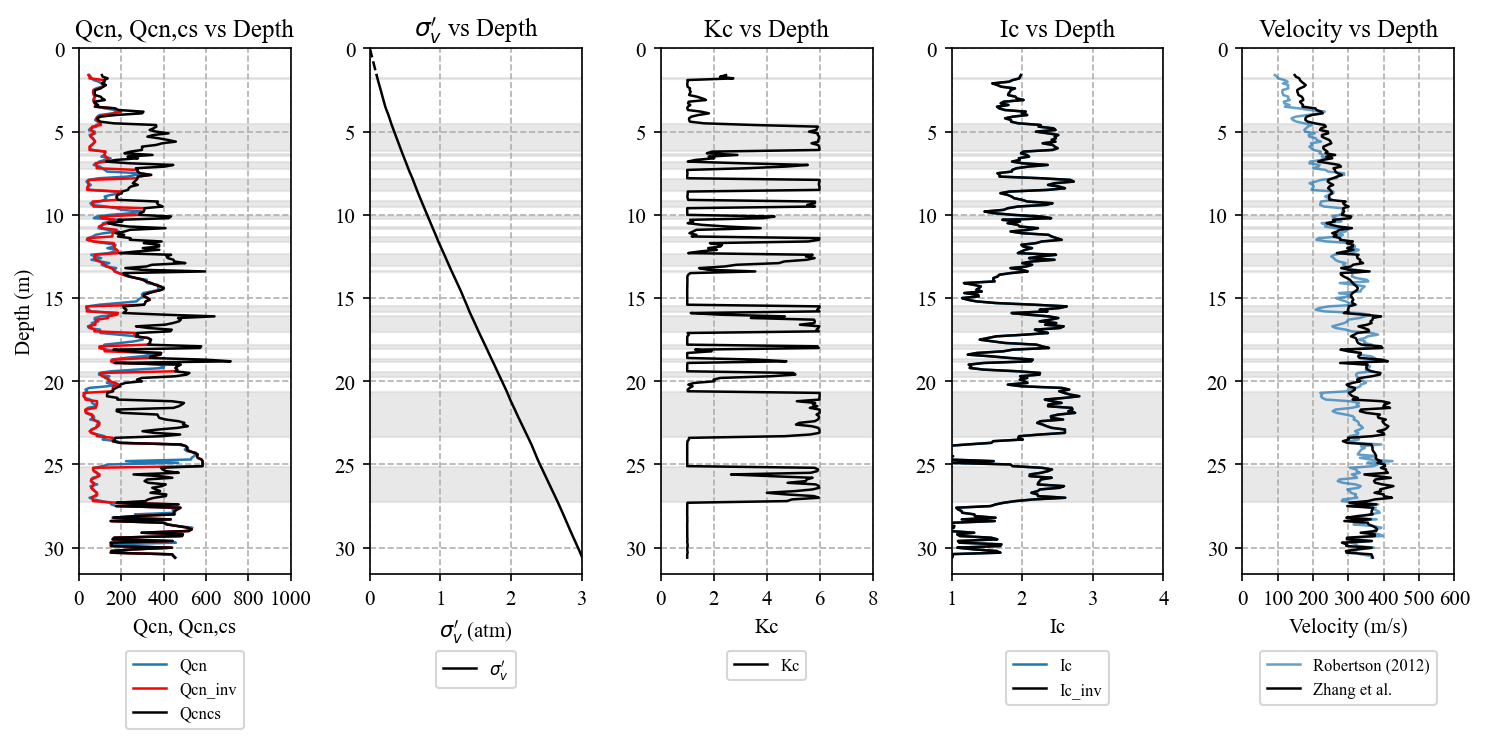

In [6]:
# using subplot to plot qt, fz, Ic, Vs with depth for the selected traveltimeMeta_ID
fig, axs = plt.subplots(1, 5, figsize=(10, 5), dpi=150)

# Qtn Plot
axs[0].plot(Qcn, CPT_depth, label='Qcn', linewidth = 1.2)
axs[0].plot(Qcn_inv, CPT_depth, label='Qcn_inv', color='red', linewidth = 1.2)
axs[0].plot(Qcncs[index], CPT_depth[index], label='Qcncs', color='black', linewidth = 1.2)
axs[0].set_xlim(0, 1000)
axs[0].set_xticks(np.arange(0, 1001, 200))
axs[0].grid(True, which="both", ls="--")
axs[0].set_xlabel('Qcn, Qcn,cs')
axs[0].set_ylabel('Depth (m)')
axs[0].set_title('Qcn, Qcn,cs vs Depth')
axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), fontsize=8)

# Adding shading for Ic > 2.6
shade_depth = CPT_depth[index]
shade_mask = kc[index] > 2.6

if len(shade_depth) > 1:
    depth_edges = np.empty(len(shade_depth) + 1)
    depth_edges[1:-1] = 0.5 * (shade_depth[:-1] + shade_depth[1:])
    depth_edges[0] = shade_depth[0] - 0.5 * (shade_depth[1] - shade_depth[0])
    depth_edges[-1] = shade_depth[-1] + 0.5 * (shade_depth[-1] - shade_depth[-2])

    start = None
    for i, flag in enumerate(shade_mask):
        if flag and start is None:
            start = depth_edges[i]
        if start is not None and ((not flag) or i == len(shade_mask) - 1):
            end = depth_edges[i] if not flag else depth_edges[i + 1]
            for ax in axs:
                ax.axhspan(start, end, color='lightgray', alpha=0.5, zorder=0)
            start = None

# σv' Plot
axs[1].plot((0, fz[0]), (0, CPT_depth[0]), color='black', linestyle='dashed', linewidth = 1.2)
axs[1].plot(fz, CPT_depth, label='$\\sigma_v^\\prime$', color='black', linewidth = 1.2)
axs[1].set_xlim(0, 3)
axs[1].set_xticks(np.arange(0, 4, 1))
axs[1].grid(True, which="both", ls="--")
axs[1].set_xlabel('$\\sigma_v^\\prime$ (atm)')
axs[1].set_title('$\\sigma_v^\\prime$ vs Depth')
axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), fontsize=8)

# Kc Plot
axs[2].plot(kc[index], CPT_depth[index], label='Kc', color = 'black', linewidth = 1.2)
axs[2].set_xlim(0, 8)
axs[2].set_xticks(np.arange(0, 9, 2))
axs[2].grid(True, which="both", ls="--")
axs[2].set_xlabel('Kc')
axs[2].set_title('Kc vs Depth')
axs[2].legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), fontsize=8)

# Ic Plot
axs[3].plot(Ic_Robertson, CPT_depth, label='Ic', linewidth = 1.2)
axs[3].plot(Ic[index], CPT_depth[index], label='Ic_inv', color = 'black', linewidth = 1.2)
axs[3].set_xlim(1, 4)
axs[3].set_xlabel('Ic')
axs[3].set_title('Ic vs Depth')
axs[3].legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), fontsize=8)
axs[3].grid(True, which="both", ls="--")

# Vs Plot
axs[4].plot(Vs_Robertson, CPT_depth, label = 'Robertson (2012)', alpha=0.7, linewidth = 1.2)
axs[4].plot(np.exp(global_velocity), CPT_depth[index], label='Zhang et al.', color='black', linewidth = 1.2)
axs[4].set_xlim(0, 600)
axs[4].set_xticks(np.arange(0, 601, 100))
axs[4].set_xlabel('Velocity (m/s)')
axs[4].set_title('Velocity vs Depth')
axs[4].legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), fontsize=8)
axs[4].grid(True, which="both", ls="--")


# Share common y-axis limits across all subplots
y_min = np.nanmin(np.nanmin(CPT_depth))
y_max = np.nanmax(np.nanmax(CPT_depth))
for ax in axs:
    ax.set_ylim(y_max + 1, 0)  # inverted depth axis, same range for all

plt.subplots_adjust(bottom=0.28, wspace=0.35)
plt.tight_layout()
plt.show()

In [47]:
# Export the computed results to a new .csv file
output_df = pd.DataFrame({
    'Depth (m)': CPT_depth[index],
    'Qcncs': Qcncs[index],
    'Ic': Ic[index],
    'sigma_vp (atm)': fz[index],
    'Vs (m/s)': np.exp(global_velocity)
})

output_df.to_csv('sample_1788_results.csv', index=False)